# 02 — Training and Evaluation (OULAD Recommender Project)

This notebook summarises the model training, evaluation, cross-validation,
and recommendation outputs for the final recommendation engine.

## Objectives

This notebook is used to:

- inspect saved single-split metrics
- inspect cross-validation results
- visualise model performance
- compare content, hybrid, popularity, and matrix factorisation approaches
- inspect sample recommendation outputs

In [1]:

import os
import json
import pandas as pd
import matplotlib.pyplot as plt

METRICS_PATH = "../metrics/metrics.json"
CV_RESULTS_PATH = "../metrics/cv_results.json"
RECOMMENDATIONS_DIR = "../recommendations"
FIGURES_DIR = "../figures"

with open(METRICS_PATH, "r", encoding="utf-8") as f:
    metrics = json.load(f)

with open(CV_RESULTS_PATH, "r", encoding="utf-8") as f:
    cv_results = json.load(f)

metrics

{'popularity': {'precision@10': 0.018525094696969696,
  'recall@10': 0.02249260105073479,
  'ndcg@10': 0.023568502300342735,
  'evaluated_users': 25344},
 'content': {'precision@10': 0.08557844065656568,
  'recall@10': 0.06937593720195998,
  'ndcg@10': 0.09797848769404581,
  'evaluated_users': 25344},
 'mf': {'precision@10': 0.01308001893939394,
  'recall@10': 0.012691314467761167,
  'ndcg@10': 0.01542162036074015,
  'evaluated_users': 25344,
  'rmse': 0.30457974827114476},
 'hybrid': {'precision@10': 0.09606613005050504,
  'recall@10': 0.0718519446705909,
  'ndcg@10': 0.10460006489767301,
  'evaluated_users': 25344}}

## Single split evaluation

In [2]:

single_split_rows = []
for model_name, vals in metrics.items():
    row = {"model": model_name}
    row.update(vals)
    single_split_rows.append(row)

single_split_df = pd.DataFrame(single_split_rows)
single_split_df

,model,precision@10,recall@10,ndcg@10,evaluated_users,rmse
0,popularity,0.018525,0.022493,0.023569,25344,NaN
1,content,0.085578,0.069376,0.097978,25344,NaN
2,mf,0.013080,0.012691,0.015422,25344,0.30458
3,hybrid,0.096066,0.071852,0.104600,25344,NaN


## Cross-validation summary

In [3]:

summary = cv_results["summary"]

cv_rows = []
for model_name, metric_block in summary.items():
    row = {"model": model_name}
    for metric_name, vals in metric_block.items():
        row[f"{metric_name}_mean"] = vals["mean"]
        row[f"{metric_name}_std"] = vals["std"]
    cv_rows.append(row)

cv_df = pd.DataFrame(cv_rows)
cv_df

,model,precision@10_mean,precision@10_std,recall@10_mean,recall@10_std,ndcg@10_mean,ndcg@10_std,evaluated_users_mean,evaluated_users_std,rmse_mean,rmse_std
0,popularity,0.017618,0.006759,0.011445,0.003156,0.018777,0.005816,8448.0,0.0,NaN,NaN
1,content,0.096267,0.002129,0.076077,0.000397,0.107414,0.002213,8448.0,0.0,NaN,NaN
2,mf,0.017061,0.004463,0.008644,0.001295,0.021252,0.005926,8448.0,0.0,0.301414,0.002431
3,hybrid,0.096121,0.002101,0.075944,0.000407,0.107279,0.002131,8448.0,0.0,NaN,NaN


## Interpretation note

The matrix factorisation model is evaluated using both ranking metrics and RMSE because it learns from pseudo-ratings derived from engagement signals.  
However, since OULAD primarily contains implicit interaction behaviour rather than true explicit preference ratings, ranking metrics are more important than RMSE when judging recommendation quality.

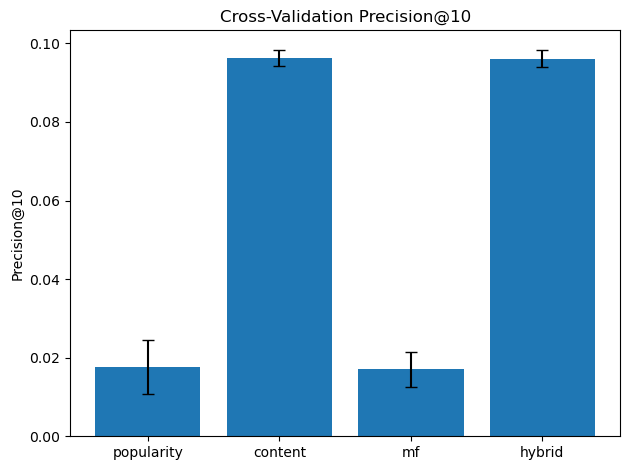

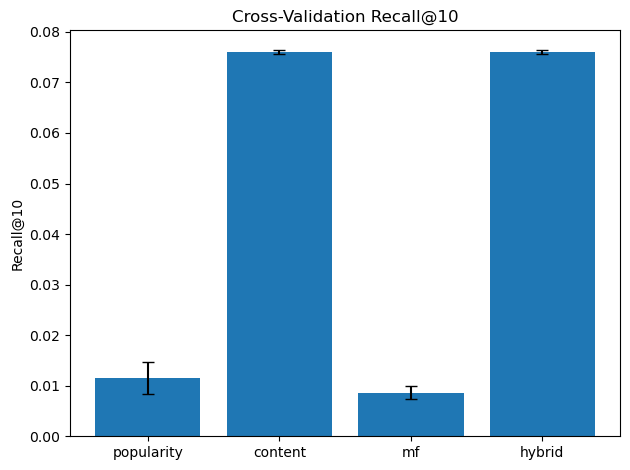

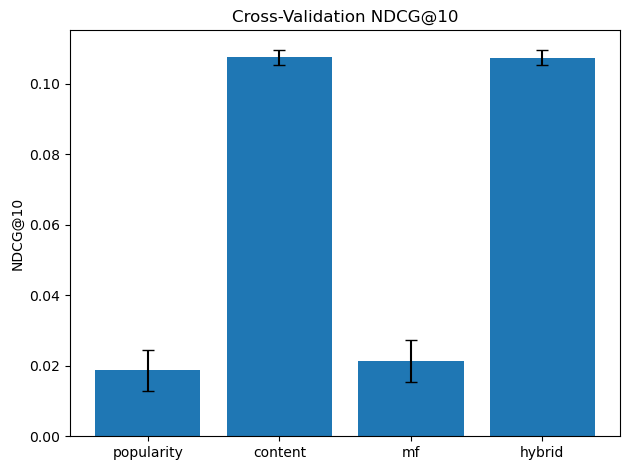

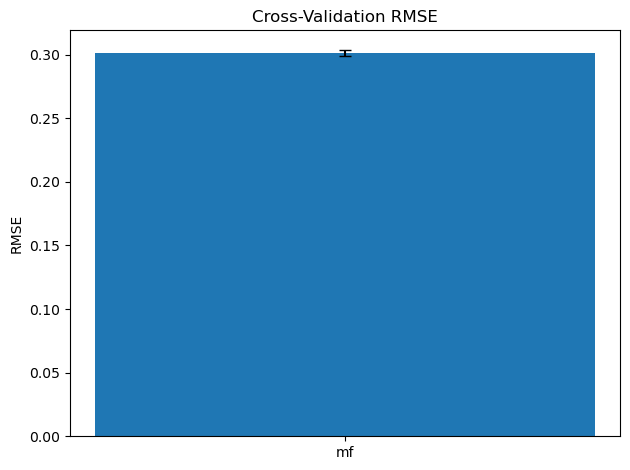

In [4]:

def plot_cv_metric(metric_name, title, ylabel, filename):
    model_names = []
    means = []
    stds = []

    for model_name, metric_block in summary.items():
        if metric_name in metric_block:
            model_names.append(model_name)
            means.append(metric_block[metric_name]["mean"])
            stds.append(metric_block[metric_name]["std"])

    plt.figure()
    plt.bar(model_names, means, yerr=stds, capsize=4)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, filename), dpi=200)
    plt.show()

plot_cv_metric("precision@10", "Cross-Validation Precision@10", "Precision@10", "notebook_precision_at_10.png")
plot_cv_metric("recall@10", "Cross-Validation Recall@10", "Recall@10", "notebook_recall_at_10.png")
plot_cv_metric("ndcg@10", "Cross-Validation NDCG@10", "NDCG@10", "notebook_ndcg_at_10.png")
plot_cv_metric("rmse", "Cross-Validation RMSE", "RMSE", "notebook_rmse.png")

## Best model identification

In [5]:

ranking_metrics = ["precision@10_mean", "recall@10_mean", "ndcg@10_mean"]
cv_rank_view = cv_df[["model"] + ranking_metrics].copy()
cv_rank_view.sort_values("ndcg@10_mean", ascending=False)

,model,precision@10_mean,recall@10_mean,ndcg@10_mean
1,content,0.096267,0.076077,0.107414
3,hybrid,0.096121,0.075944,0.107279
2,mf,0.017061,0.008644,0.021252
0,popularity,0.017618,0.011445,0.018777


## Sample recommendation outputs

This section reads any previously saved recommendation files produced by
`src/demo_recommend.py`.

In [6]:

rec_files = sorted([f for f in os.listdir(RECOMMENDATIONS_DIR) if f.endswith(".csv")]) if os.path.exists(RECOMMENDATIONS_DIR) else []
rec_files

['user_28400_content_recommendations.csv',
 'user_28400_history.csv',
 'user_28400_hybrid_recommendations.csv']

In [7]:

if rec_files:
    sample_path = os.path.join(RECOMMENDATIONS_DIR, rec_files[0])
    sample_df = pd.read_csv(sample_path)
    print("Showing:", sample_path)
    display(sample_df.head(10))

Showing: ../recommendations\user_28400_content_recommendations.csv


,item_id,title,activity_type,code_module,code_presentation,description,tags,score
0,AAA_2013J_546726,Oucontent Resource,oucontent,AAA,2013J,Educational resource of type oucontent for mod...,"oucontent,AAA,2013J",0.904140
1,AAA_2013J_546704,Oucontent Resource,oucontent,AAA,2013J,Educational resource of type oucontent for mod...,"oucontent,AAA,2013J",0.896578
2,AAA_2013J_546701,Oucontent Resource,oucontent,AAA,2013J,Educational resource of type oucontent for mod...,"oucontent,AAA,2013J",0.896040
3,AAA_2013J_546709,Oucontent Resource,oucontent,AAA,2013J,Educational resource of type oucontent for mod...,"oucontent,AAA,2013J",0.881988
4,AAA_2013J_546974,Resource Resource,resource,AAA,2013J,Educational resource of type resource for modu...,"resource,AAA,2013J",0.763259
5,AAA_2013J_546995,Resource Resource,resource,AAA,2013J,Educational resource of type resource for modu...,"resource,AAA,2013J",0.763259
6,AAA_2013J_547043,Resource Resource,resource,AAA,2013J,Educational resource of type resource for modu...,"resource,AAA,2013J",0.763259
7,AAA_2013J_547018,Resource Resource,resource,AAA,2013J,Educational resource of type resource for modu...,"resource,AAA,2013J",0.740501
8,AAA_2013J_546670,Oucontent Resource,oucontent,AAA,2013J,Educational resource of type oucontent for mod...,"oucontent,AAA,2013J",0.872825
9,AAA_2013J_546706,Oucontent Resource,oucontent,AAA,2013J,Educational resource of type oucontent for mod...,"oucontent,AAA,2013J",0.867896


## Suggested written conclusions

Adapt these statements in the final report:

- The popularity baseline performs poorly because it ignores user-specific preferences.
- Matrix factorisation achieves a low RMSE but weak ranking performance, indicating that pseudo-ratings are less effective for top-N recommendation than for score approximation.
- The content-based model performs strongly because OULAD provides meaningful metadata such as activity type, module, and presentation.
- After feature engineering and diversity-aware reranking, the hybrid model becomes competitive with the content-based model and offers the strongest overall final-system story.